In [1]:
# ------------------------------------------------------------
# Task 2D: Inspect Animal 9 decoder output
#
# Mission:
# We want to verify whether the Animal 9 decoder is producing
# biologically reasonable signals before moving into ML.
#
# Since the ERP plot looked suspicious (no clear M-wave or
# H-reflex peaks), this step helps us diagnose whether the
# decoder output is valid or if something may be wrong with:
#
# - record counting
# - signal offsets
# - baseline subtraction
# - trial selection
#
# We will:
# 1. Load Animal 9 using decoder_2006.py
# 2. Check signal array shape
# 3. Separate muscle (Ch1) and brain (Ch2)
# 4. Print signal statistics (min/max/mean)
# 5. Measure peak amplitudes
#
# Goal:
# Determine whether decoded signals look biologically realistic.
# ------------------------------------------------------------


# Import the Animal 9 decoder function
# This is the function that converts the raw .MYD file
# into usable signal arrays.
from decoders.decoder_2006 import decode_frag1

# Import NumPy for statistics and numerical analysis
import numpy as np


# ------------------------------------------------------------
# Step 1: Define path to Animal 9 data file
#
# This tells Python where the raw .MYD signal file is located.
# ------------------------------------------------------------
myd_path = "data/raw/ani-emg-eeg-9/emg-eeg-9-data.MYD"


# ------------------------------------------------------------
# Step 2: Decode the raw .MYD file
#
# decode_frag1() does the following:
# - reads the binary .MYD file
# - interprets bytes as big-endian int16 values
# - converts raw values to microvolts using AD2UV
# - separates Channel 1 (muscle) and Channel 2 (brain)
# - organizes data into trial arrays
#
# fix_baseline=False:
# We are leaving baseline correction OFF for now because
# Animal 9 has a known baseline subtraction bug that still
# needs validation.
# ------------------------------------------------------------
signals = decode_frag1(myd_path, fix_baseline=False)


# ------------------------------------------------------------
# Step 3: Check overall signal shape
#
# Expected shape:
# (n_trials, 2, 150)
#
# Meaning:
# n_trials = total number of decoded trials
# 2 = two channels (muscle + brain)
# 150 = samples per trial
#
# This confirms whether the decoder output structure
# looks correct.
# ------------------------------------------------------------
print("Signals shape:", signals.shape)

# Print total number of decoded trials
print("Number of records/trials decoded:", signals.shape[0])


# ------------------------------------------------------------
# Step 4: Separate Channel 1 and Channel 2
#
# Channel 1 = SOLR EMG (muscle signal)
# Channel 2 = ECoG (brain signal)
#
# ":" means:
# "take everything"
#
# signals[:, 0, :]
# = all trials, channel 1, all time samples
#
# signals[:, 1, :]
# = all trials, channel 2, all time samples
# ------------------------------------------------------------
ch1 = signals[:, 0, :]   # Muscle signal
ch2 = signals[:, 1, :]   # Brain signal


# ------------------------------------------------------------
# Step 5: Verify channel shapes
#
# We want to make sure both channels have the
# expected dimensions.
# ------------------------------------------------------------
print("Channel 1 shape (muscle):", ch1.shape)
print("Channel 2 shape (brain):", ch2.shape)


# ------------------------------------------------------------
# Step 6: Inspect signal ranges
#
# We calculate:
#
# Min = smallest signal value
# Max = largest signal value
# Mean = average signal level
#
# Purpose:
# Helps determine whether values look biologically
# realistic or suspiciously large/incorrect.
# ------------------------------------------------------------

print("\n--- Channel 1 (Muscle / EMG) Statistics ---")
print("Minimum value:", np.min(ch1))
print("Maximum value:", np.max(ch1))
print("Mean value:", np.mean(ch1))

print("\n--- Channel 2 (Brain / ECoG) Statistics ---")
print("Minimum value:", np.min(ch2))
print("Maximum value:", np.max(ch2))
print("Mean value:", np.mean(ch2))


# ------------------------------------------------------------
# Step 7: Compute peak signal amplitudes
#
# We use absolute value because biological signals
# can go positive or negative.
#
# Example:
# [-200, +350]
#
# Peak amplitude should be:
# 350 (largest magnitude)
#
# Purpose:
# Check whether signal amplitudes fall within
# biologically realistic ranges.
#
# Expectations:
#
# Channel 1 (EMG muscle):
# typically hundreds of µV
#
# Channel 2 (brain ECoG):
# around ±300 µV
# ------------------------------------------------------------
print("\n--- Peak Absolute Amplitudes ---")

print(
    "Channel 1 peak absolute amplitude:",
    np.max(np.abs(ch1)),
    "µV"
)

print(
    "Channel 2 peak absolute amplitude:",
    np.max(np.abs(ch2)),
    "µV"
)

Found 286353 records in emg-eeg-9-data.MYD
Signals shape: (286353, 2, 150)
Number of records/trials decoded: 286353
Channel 1 shape (muscle): (286353, 150)
Channel 2 shape (brain): (286353, 150)

--- Channel 1 (Muscle / EMG) Statistics ---
Minimum value: -79999.99
Maximum value: 79997.555
Mean value: 9639.371

--- Channel 2 (Brain / ECoG) Statistics ---
Minimum value: -79999.99
Maximum value: 79997.555
Mean value: 9637.034

--- Peak Absolute Amplitudes ---
Channel 1 peak absolute amplitude: 79999.99 µV
Channel 2 peak absolute amplitude: 79999.99 µV


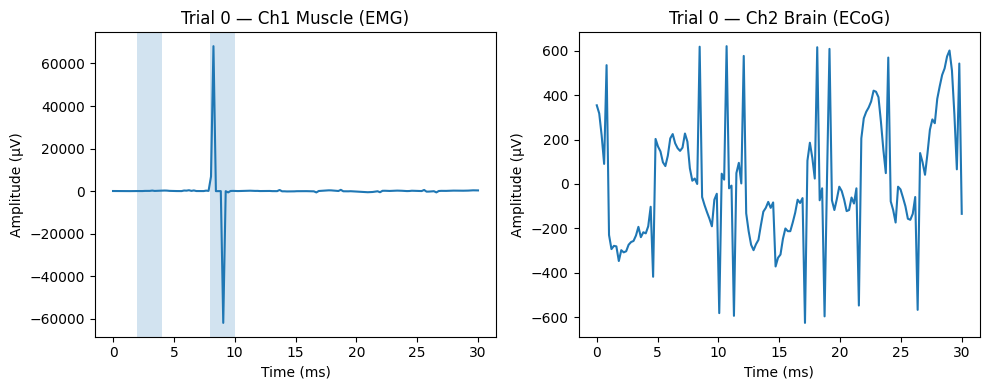

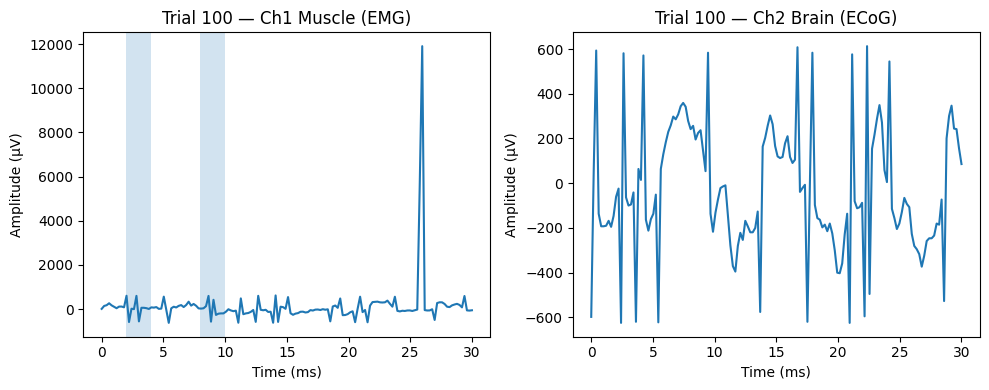

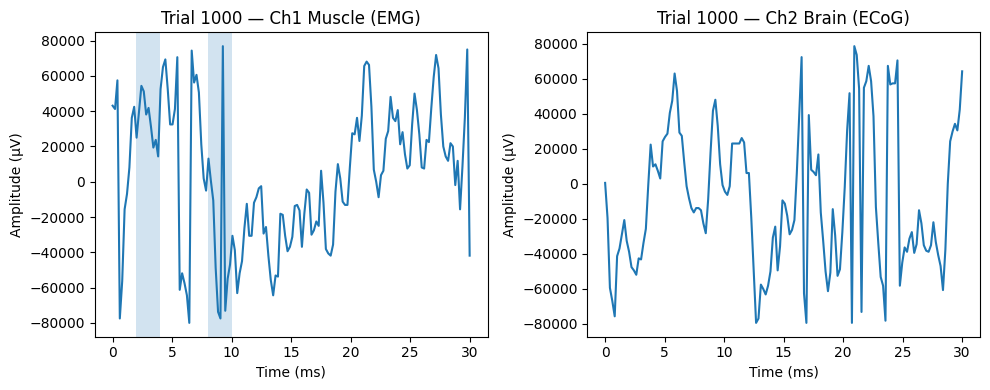

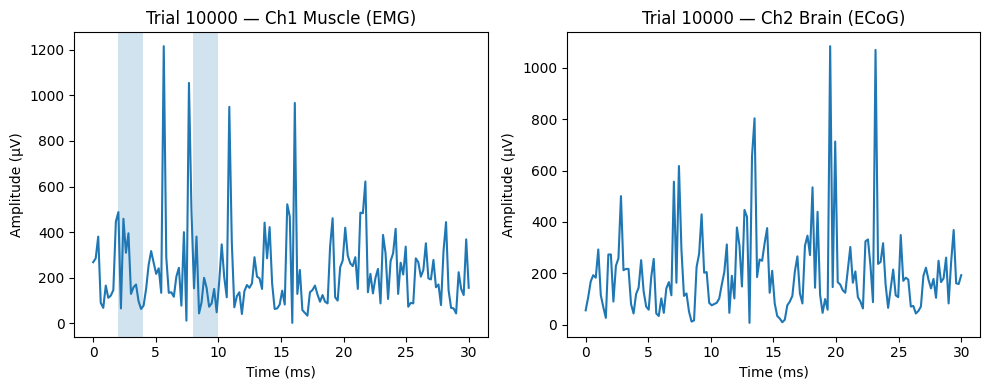

In [2]:
# ------------------------------------------------------------
# Task 2E: Inspect individual Animal 9 trials
#
# Mission:
# Instead of averaging across all trials, we want to
# inspect raw individual trials to see whether real
# biological signal structure exists.
#
# Why?
# The ERP average looked suspicious and did not show
# clear M-wave or H-reflex peaks.
#
# Sometimes averages hide real biology if:
# - bad trials are included
# - signals are misaligned
# - non-stimulus records are mixed in
#
# Goal:
# Check whether individual trials contain meaningful
# muscle and brain signals.
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Step 1: Create time axis
#
# Animal 9 has:
# 150 samples at 5000 Hz
#
# 5000 Hz means:
# 5000 samples per second
#
# Total window:
# 150 / 5000 = 0.03 sec = 30 ms
#
# We create a time axis from 0 → 30 ms
# so plots are interpretable.
# ------------------------------------------------------------
time_ms = np.linspace(0, 30, 150)


# ------------------------------------------------------------
# Step 2: Choose a few example trials
#
# We do NOT want to plot all 286k trials.
#
# Instead, inspect a few raw examples.
#
# These are arbitrary trial indices.
# We can change them later if needed.
# ------------------------------------------------------------
trial_indices = [0, 100, 1000, 10000]


# ------------------------------------------------------------
# Step 3: Plot raw muscle and brain signals
#
# Channel 1 = muscle (EMG)
# Channel 2 = brain (ECoG)
#
# Goal:
# Look for:
#
# Channel 1:
# - M-wave (2–4 ms)
# - H-reflex (8–10 ms)
#
# Channel 2:
# - non-random, time-locked response
# ------------------------------------------------------------
for trial in trial_indices:

    plt.figure(figsize=(10,4))

    # Channel 1 (muscle)
    plt.subplot(1,2,1)
    plt.plot(time_ms, signals[trial, 0, :])
    plt.title(f"Trial {trial} — Ch1 Muscle (EMG)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")

    # Mark expected biological windows
    plt.axvspan(2, 4, alpha=0.2)
    plt.axvspan(8, 10, alpha=0.2)

    # Channel 2 (brain)
    plt.subplot(1,2,2)
    plt.plot(time_ms, signals[trial, 1, :])
    plt.title(f"Trial {trial} — Ch2 Brain (ECoG)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")

    plt.tight_layout()
    plt.show()

Group 0: 95451 records


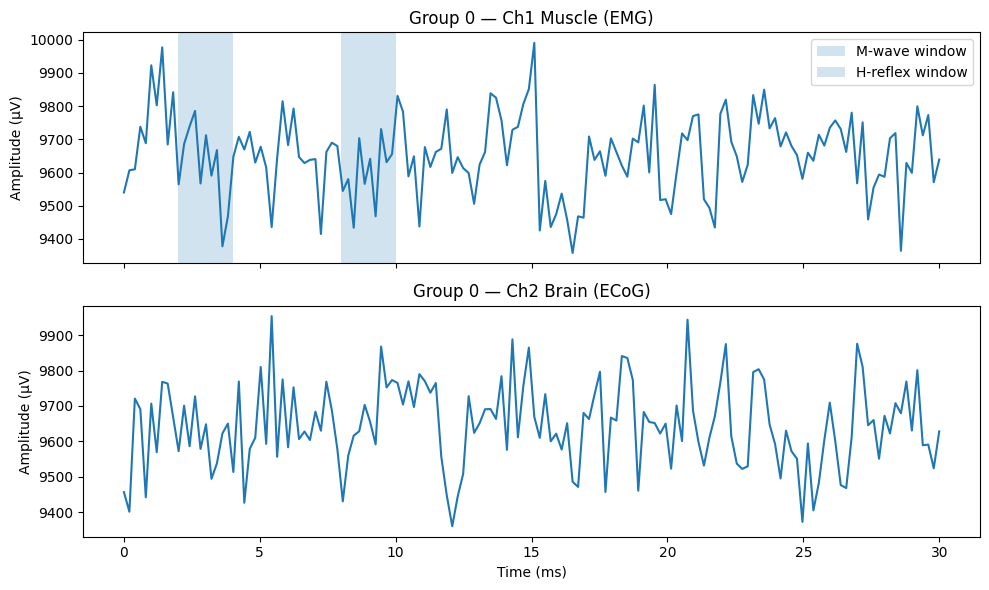

Group 1: 95451 records


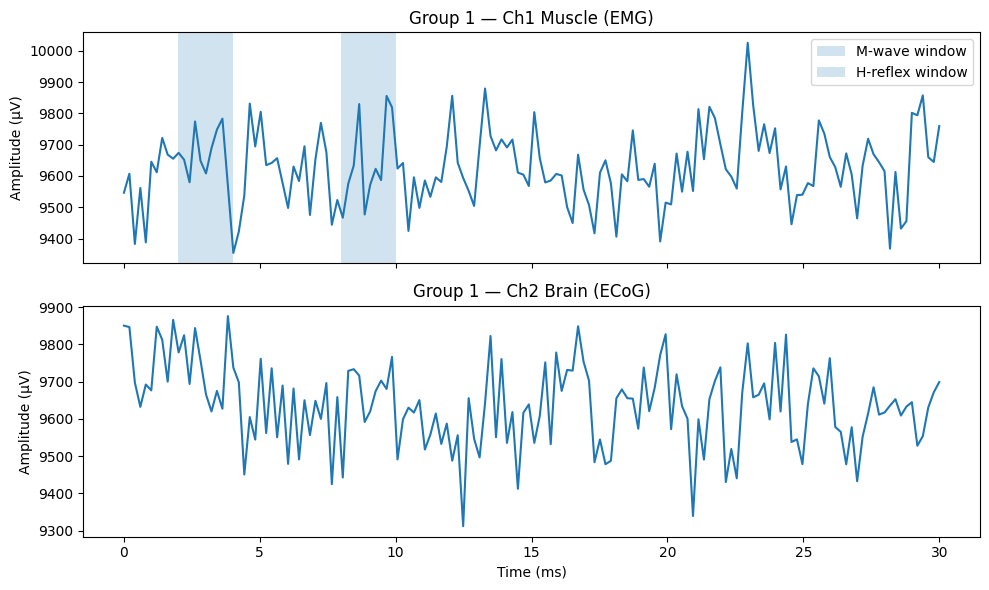

Group 2: 95451 records


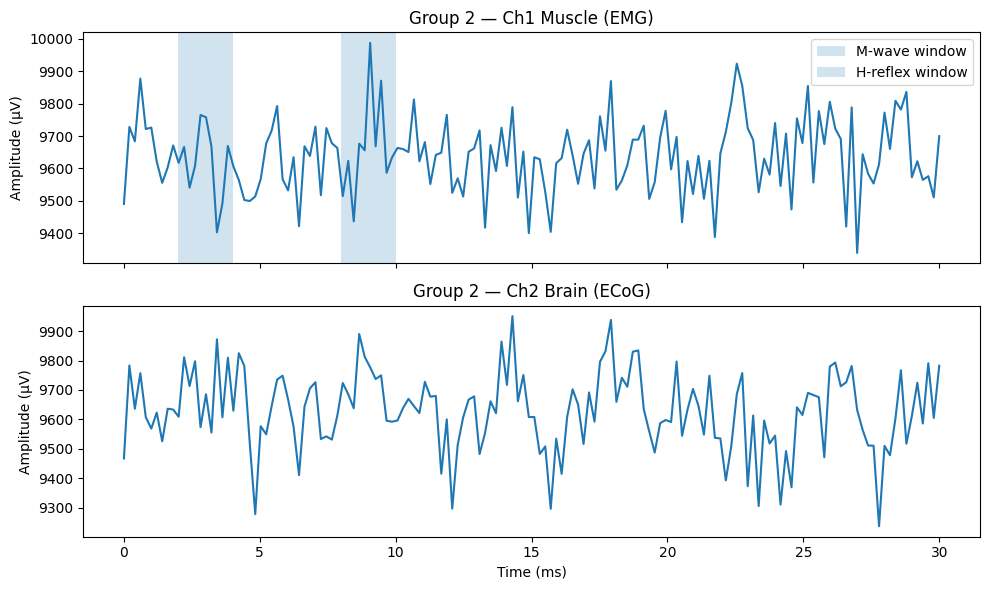

In [3]:
# ------------------------------------------------------------
# Task 2G: Test every-3rd-record hypothesis
#
# Mission:
# The decoder found 286,353 records, but the roadmap says
# Animal 9 should have around 95,450 trials.
#
# Since 286,353 / 3 ≈ 95,451, we are testing whether the
# true biological trials may be every 3rd record.
#
# We will create 3 separate groups:
#
# Group 0 = records 0, 3, 6, 9, ...
# Group 1 = records 1, 4, 7, 10, ...
# Group 2 = records 2, 5, 8, 11, ...
#
# Then we average each group separately and check which one
# gives the most biologically realistic ERP.
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Create time axis from 0 to 30 ms
time_ms = np.linspace(0, 30, signals.shape[2])

# Loop through 3 possible record groups
for group in range(3):

    # Select every 3rd record starting at this group
    subset = signals[group::3]

    print(f"Group {group}: {subset.shape[0]} records")

    # Average selected records
    avg = subset.mean(axis=0)

    # Plot average Channel 1 and Channel 2
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(time_ms, avg[0])
    axes[0].set_title(f"Group {group} — Ch1 Muscle (EMG)")
    axes[0].set_ylabel("Amplitude (µV)")

    # Highlight M-wave and H-reflex windows
    axes[0].axvspan(2, 4, alpha=0.2, label="M-wave window")
    axes[0].axvspan(8, 10, alpha=0.2, label="H-reflex window")
    axes[0].legend()

    axes[1].plot(time_ms, avg[1])
    axes[1].set_title(f"Group {group} — Ch2 Brain (ECoG)")
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Amplitude (µV)")

    plt.tight_layout()
    plt.show()

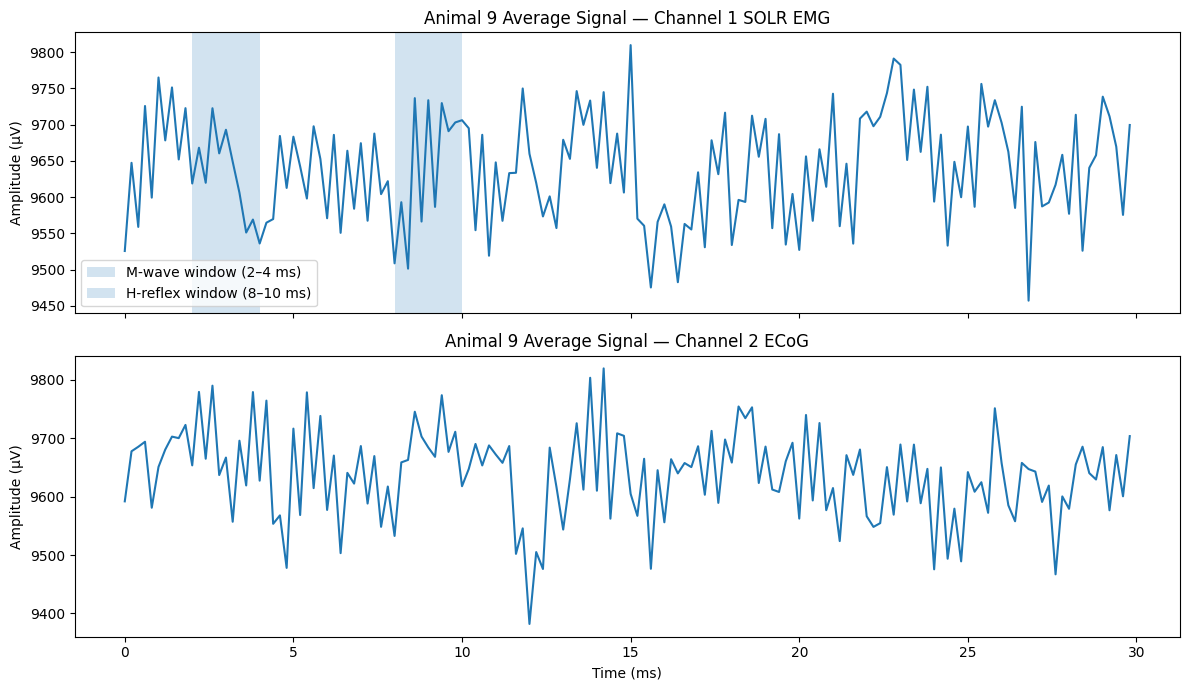

Saved figure to: figures/animal9_average_signals.png


In [4]:
# ------------------------------------------------------------
# Task 3A: Compute and plot average Animal 9 signals
#
# Mission:
# Compute the average signal across all decoded Animal 9 trials
# and plot both channels with proper axes.
#
# This directly addresses the requirement:
# "In a new cell, compute the average signal across all trials
# and plot both. Label axis properly (milliseconds x axis,
# amplitude uV), save graphs into figures folder."
#
# Channel 1 = SOLR EMG muscle signal
# Channel 2 = ECoG brain signal
#
# The main biological question:
# Do we see two peaks in Channel 1?
# - M-wave: expected around 2–4 ms
# - H-reflex: expected around 8–10 ms
# ------------------------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Step 1: Create figures folder if it does not exist
#
# This ensures the plot is saved into the required folder.
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)


# ------------------------------------------------------------
# Step 2: Create time axis in milliseconds
#
# Animal 9 signal:
# - 150 samples per trial
# - 5000 Hz sample rate
#
# 5000 Hz = 5000 samples per second
# 150 samples / 5000 Hz = 0.03 seconds = 30 ms
#
# So x-axis should run from 0 to 30 ms.
# ------------------------------------------------------------
sample_rate = 5000
n_samples = signals.shape[2]

time_ms = np.arange(n_samples) / sample_rate * 1000


# ------------------------------------------------------------
# Step 3: Compute average signal across all trials
#
# signals shape is:
# (n_trials, 2, 150)
#
# axis=0 means:
# average across all trials
#
# Result shape becomes:
# (2, 150)
#
# avg_signal[0] = average Channel 1 muscle signal
# avg_signal[1] = average Channel 2 brain signal
# ------------------------------------------------------------
avg_signal = signals.mean(axis=0)

avg_ch1 = avg_signal[0]  # Channel 1 = SOLR EMG muscle
avg_ch2 = avg_signal[1]  # Channel 2 = ECoG brain


# ------------------------------------------------------------
# Step 4: Plot both average signals
#
# We use two separate subplots:
# - top plot = Channel 1 muscle
# - bottom plot = Channel 2 brain
#
# We label:
# - x-axis = Time (ms)
# - y-axis = Amplitude (µV)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time_ms, avg_ch1)
axes[0].set_title("Animal 9 Average Signal — Channel 1 SOLR EMG")
axes[0].set_ylabel("Amplitude (µV)")

# Mark expected M-wave and H-reflex windows
axes[0].axvspan(2, 4, alpha=0.2, label="M-wave window (2–4 ms)")
axes[0].axvspan(8, 10, alpha=0.2, label="H-reflex window (8–10 ms)")
axes[0].legend()

axes[1].plot(time_ms, avg_ch2)
axes[1].set_title("Animal 9 Average Signal — Channel 2 ECoG")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Amplitude (µV)")

plt.tight_layout()


# ------------------------------------------------------------
# Step 5: Save figure into figures folder
#
# This satisfies the requirement to save graphs into
# the figures folder.
# ------------------------------------------------------------
output_path = "figures/animal9_average_signals.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Saved figure to: {output_path}")

H-reflex window in samples: 40 to 50
Number of H-reflex amplitudes extracted: 286353
Minimum H-reflex amplitude: 7.324218 µV
Maximum H-reflex amplitude: 79999.99 µV
Mean H-reflex amplitude: 51879.977 µV
Median H-reflex amplitude: 59374.996 µV


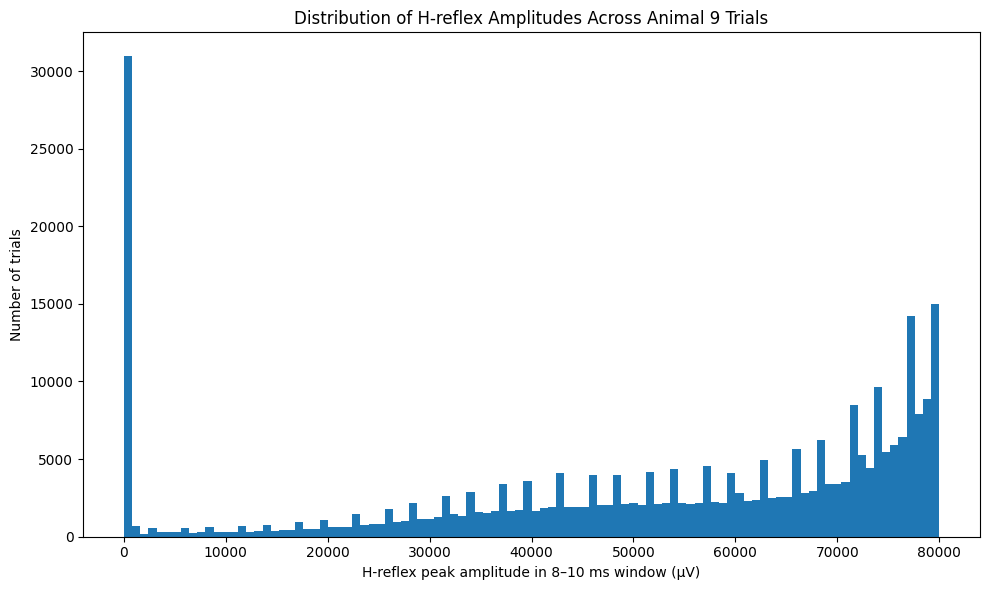

Saved histogram to: figures/animal9_h_reflex_amplitude_histogram.png


In [5]:
# ------------------------------------------------------------
# Task 4: Extract H-reflex amplitude for every trial
#
# Mission:
# The H-reflex should appear in Channel 1 between 8–10 ms
# after stimulation.
#
# We will:
# 1. Use Channel 1 only because Channel 1 = SOLR EMG muscle signal
# 2. Convert the 8–10 ms time window into sample indices
# 3. Find the peak amplitude inside that window for every trial
# 4. Plot a histogram showing the distribution of H-reflex amplitudes
#
# Requirement:
# "The H reflex appears between 8-10 milliseconds after stimulus,
# write code that finds the peak amplitude of channel one within
# that time window for every trial. Plot histogram showing distribution
# of H reflex amplitudes across all trials."
# ------------------------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Step 1: Create figures folder if it does not already exist
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)


# ------------------------------------------------------------
# Step 2: Define sample rate and H-reflex time window
#
# Animal 9 sample rate = 5000 Hz
# This means 5000 samples per second.
#
# H-reflex expected window:
# 8–10 ms after stimulus
# ------------------------------------------------------------
sample_rate = 5000

h_start_ms = 8
h_end_ms = 10


# ------------------------------------------------------------
# Step 3: Convert milliseconds into sample indices
#
# Formula:
# sample index = time_seconds * sample_rate
#
# 8 ms = 0.008 seconds
# 10 ms = 0.010 seconds
#
# At 5000 Hz:
# 8 ms  -> sample 40
# 10 ms -> sample 50
#
# So we will search Channel 1 samples 40–50.
# ------------------------------------------------------------
h_start_idx = int((h_start_ms / 1000) * sample_rate)
h_end_idx = int((h_end_ms / 1000) * sample_rate)

print("H-reflex window in samples:", h_start_idx, "to", h_end_idx)


# ------------------------------------------------------------
# Step 4: Select Channel 1
#
# signals shape:
# (n_trials, 2, 150)
#
# signals[:, 0, :]
# means:
# all trials, Channel 1, all time samples
#
# Channel 1 = SOLR EMG muscle signal
# ------------------------------------------------------------
ch1 = signals[:, 0, :]


# ------------------------------------------------------------
# Step 5: Extract the H-reflex window from every trial
#
# This creates a smaller array containing only the 8–10 ms
# part of Channel 1 for every trial.
#
# Shape should be:
# (n_trials, about 10 samples)
# ------------------------------------------------------------
h_window = ch1[:, h_start_idx:h_end_idx]


# ------------------------------------------------------------
# Step 6: Find peak H-reflex amplitude for every trial
#
# We use absolute value because EMG peaks can be positive
# or negative. The strongest response may be either direction.
#
# np.max(np.abs(...), axis=1)
# means:
# for each trial, find the largest absolute amplitude inside
# the 8–10 ms H-reflex window.
# ------------------------------------------------------------
h_reflex_amplitudes = np.max(np.abs(h_window), axis=1)


# ------------------------------------------------------------
# Step 7: Print summary statistics
#
# These help us understand the range and distribution of
# extracted H-reflex amplitudes.
# ------------------------------------------------------------
print("Number of H-reflex amplitudes extracted:", len(h_reflex_amplitudes))
print("Minimum H-reflex amplitude:", np.min(h_reflex_amplitudes), "µV")
print("Maximum H-reflex amplitude:", np.max(h_reflex_amplitudes), "µV")
print("Mean H-reflex amplitude:", np.mean(h_reflex_amplitudes), "µV")
print("Median H-reflex amplitude:", np.median(h_reflex_amplitudes), "µV")


# ------------------------------------------------------------
# Step 8: Plot histogram
#
# This shows how H-reflex amplitudes are distributed across
# all decoded Animal 9 trials.
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(h_reflex_amplitudes, bins=100)

plt.title("Distribution of H-reflex Amplitudes Across Animal 9 Trials")
plt.xlabel("H-reflex peak amplitude in 8–10 ms window (µV)")
plt.ylabel("Number of trials")

plt.tight_layout()


# ------------------------------------------------------------
# Step 9: Save histogram into figures folder
# ------------------------------------------------------------
output_path = "figures/animal9_h_reflex_amplitude_histogram.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Saved histogram to: {output_path}")